In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

df = pd.read_csv("HR_Employee_Attrition.csv")
df.head(20)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [3]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [4]:
df.shape

(1470, 35)

In [5]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [6]:
print(df.columns)

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

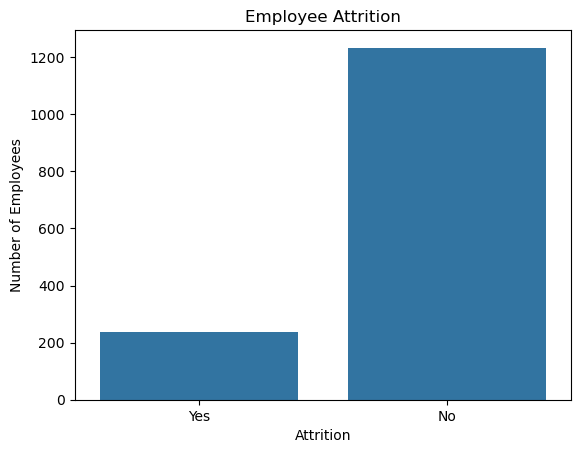

In [9]:
sns.countplot(x="Attrition", data=df)
plt.title("Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

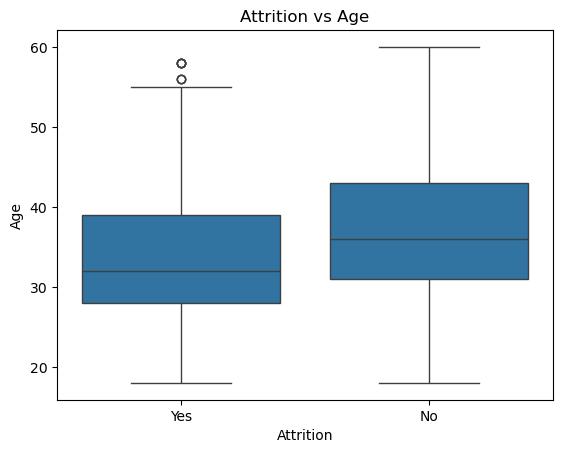

In [10]:
sns.boxplot(x="Attrition", y="Age", data=df)
plt.title("Attrition vs Age")
plt.show()

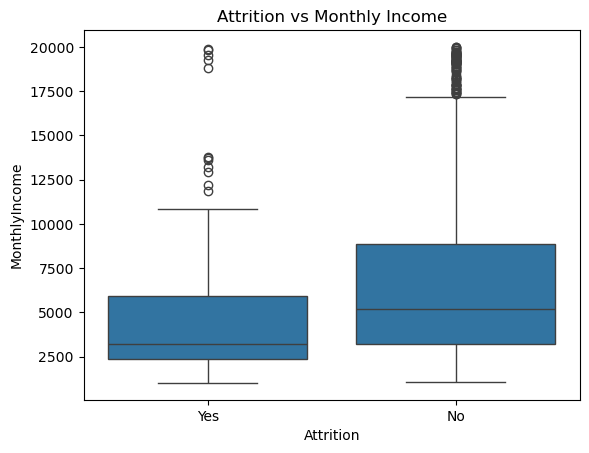

In [11]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Attrition vs Monthly Income")
plt.show()

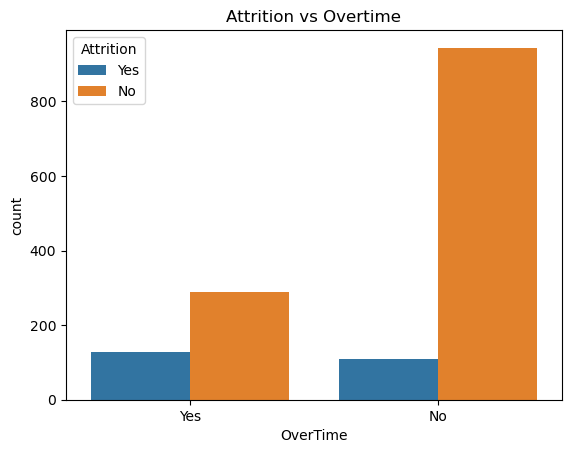

In [12]:
sns.countplot(x="OverTime", hue="Attrition", data=df)
plt.title("Attrition vs Overtime")
plt.show()

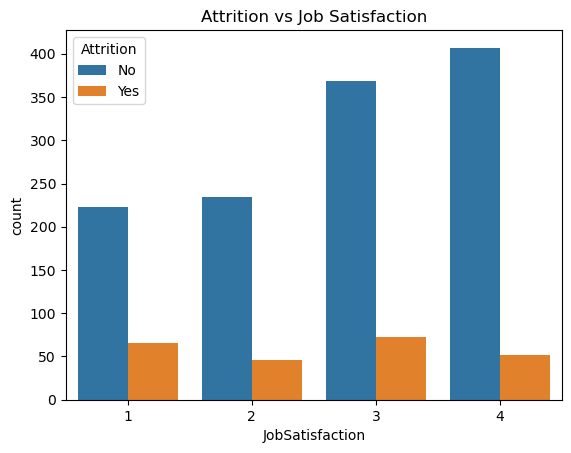

In [13]:
sns.countplot(x="JobSatisfaction", hue="Attrition", data=df)
plt.title("Attrition vs Job Satisfaction")
plt.show()

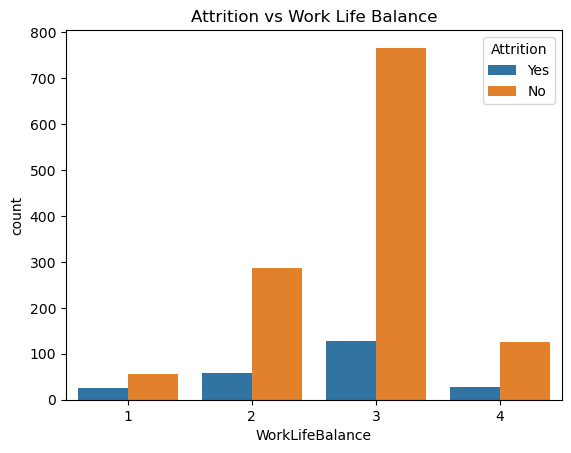

In [14]:
sns.countplot(x="WorkLifeBalance", hue="Attrition", data=df)
plt.title("Attrition vs Work Life Balance")
plt.show()

In [15]:
categorical_columns = df.select_dtypes(include="object").columns
numerical_columns = df.select_dtypes(include=np.number).columns

print(categorical_columns)
print(numerical_columns)

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [16]:
df["Attrition"] = df["Attrition"].map({"No": 0, "Yes": 1})
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [17]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

X = pd.get_dummies(X, drop_first=True)
X.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,1,1,2,94,3,2,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,1,2,3,61,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,1,4,4,92,2,1,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,1,5,4,56,3,1,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,7,1,40,3,1,...,True,False,False,False,False,False,False,True,False,False


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
X_train.shape

(1176, 47)

In [20]:
X_test.shape

(294, 47)

In [21]:
y_train.shape

(1176,)

In [22]:
y_test.shape

(294,)

In [23]:
sc = StandardScaler()

X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [24]:
X_train_sc

array([[ 1.09019402,  1.04945488, -0.89991452, ..., -0.92144268,
        -0.68154831, -0.63772923],
       [-1.6348276 , -0.52344929, -0.89991452, ...,  1.08525471,
        -0.68154831, -0.63772923],
       [ 0.98119316, -0.99208001, -0.77761018, ...,  1.08525471,
        -0.68154831, -0.63772923],
       ...,
       [-1.6348276 , -1.46320345, -0.16608847, ...,  1.08525471,
        -0.68154831, -0.63772923],
       [-0.10881549, -0.93225481, -0.89991452, ...,  1.08525471,
        -0.68154831,  1.56806362],
       [ 0.21818711, -0.09470203,  1.30156365, ..., -0.92144268,
        -0.68154831, -0.63772923]], shape=(1176, 47))

In [25]:
X_test_sc

array([[-1.41682587e+00,  6.48318281e-02,  4.45433249e-01, ...,
         1.08525471e+00, -6.81548307e-01, -6.37729225e-01],
       [ 7.63191429e-01,  7.80241491e-01, -8.99914522e-01, ...,
         1.08525471e+00, -6.81548307e-01, -6.37729225e-01],
       [-6.53819813e-01, -2.89133929e-01, -2.88392808e-01, ...,
        -9.21442675e-01, -6.81548307e-01, -6.37729225e-01],
       ...,
       [-1.08815489e-01,  1.62527242e+00,  4.45433249e-01, ...,
        -9.21442675e-01, -6.81548307e-01,  1.56806362e+00],
       [ 2.07120181e+00,  1.12423638e+00, -1.02221887e+00, ...,
         1.08525471e+00, -6.81548307e-01, -6.37729225e-01],
       [ 1.85375620e-04,  1.41588422e+00, -1.02221887e+00, ...,
        -9.21442675e-01,  1.46724743e+00, -6.37729225e-01]],
      shape=(294, 47))

In [26]:
lg_model = LogisticRegression(max_iter=1000)
lg_model.fit(X_train_sc, y_train)

y_pred_lg = lg_model.predict(X_test_sc)

In [27]:
print("Accuracy:",accuracy_score(y_test, y_pred_lg))
print("Precision:", precision_score(y_test, y_pred_lg))
print("Recall:", recall_score(y_test, y_pred_lg))
print("F1 Score:", f1_score(y_test, y_pred_lg))

Accuracy: 0.8605442176870748
Precision: 0.6153846153846154
Recall: 0.3404255319148936
F1 Score: 0.4383561643835616


In [28]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_sc, y_train)

y_pred_knn = knn_model.predict(X_test_sc)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))

Accuracy: 0.8435374149659864
Precision: 0.5555555555555556
Recall: 0.10638297872340426
F1 Score: 0.17857142857142858


In [29]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree_model.fit(X_train, y_train)
y_pred_tree = decision_tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1 Score:", f1_score(y_test, y_pred_tree))

Accuracy: 0.8333333333333334
Precision: 0.45
Recall: 0.19148936170212766
F1 Score: 0.26865671641791045


In [30]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.8299319727891157
Precision: 0.36363636363636365
Recall: 0.0851063829787234
F1 Score: 0.13793103448275862


In [31]:
gradient_model = GradientBoostingClassifier(random_state=42)
gradient_model.fit(X_train, y_train)

y_pred_gradient = gradient_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_gradient))
print("Precision:", precision_score(y_test, y_pred_gradient))
print("Recall:", recall_score(y_test, y_pred_gradient))
print("F1 Score:", f1_score(y_test, y_pred_gradient))

Accuracy: 0.8435374149659864
Precision: 0.5294117647058824
Recall: 0.19148936170212766
F1 Score: 0.28125


In [32]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lg),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gradient)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lg),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gradient)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lg),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gradient)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lg),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gradient)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.860544,0.615385,0.340426,0.438356
1,KNN,0.843537,0.555556,0.106383,0.178571
2,Decision Tree,0.833333,0.450000,0.191489,0.268657
3,Random Forest,0.829932,0.363636,0.085106,0.137931
4,Gradient Boosting,0.843537,0.529412,0.191489,0.281250


In [35]:
best_model_name = results.loc[results["F1 Score"].idxmax(), "Model"]
print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [36]:
predictions = {
    "Logistic Regression": y_pred_lg,
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gradient
}

best_predictions = predictions[best_model_name]

In [37]:
cm = confusion_matrix(y_test, best_predictions)
cm

array([[237,  10],
       [ 31,  16]])

In [39]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

In [40]:
feature_importance

,Feature,Importance
0,Age,0.059688
1,DailyRate,0.049455
2,DistanceFromHome,0.042155
3,Education,0.017899
4,EmployeeCount,0.000000
5,EmployeeNumber,0.044738
6,EnvironmentSatisfaction,0.025865
7,HourlyRate,0.044815
8,JobInvolvement,0.024643
9,JobLevel,0.020328


In [41]:
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
feature_importance

,Feature,Importance
11,MonthlyIncome,0.066978
19,TotalWorkingYears,0.065706
0,Age,0.059688
1,DailyRate,0.049455
12,MonthlyRate,0.046730
7,HourlyRate,0.044815
5,EmployeeNumber,0.044738
2,DistanceFromHome,0.042155
46,OverTime_Yes,0.037496
22,YearsAtCompany,0.037261


In [42]:
top_5 = feature_importance.head(5)
top_5

,Feature,Importance
11,MonthlyIncome,0.066978
19,TotalWorkingYears,0.065706
0,Age,0.059688
1,DailyRate,0.049455
12,MonthlyRate,0.046730


In [43]:
X.columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Male',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
  

In [44]:
df["JobSatisfaction"].value_counts()

JobSatisfaction
4    459
3    442
1    289
2    280
Name: count, dtype: int64

In [47]:
new_employee = {
    "Age": 30,
    "BusinessTravel": "Travel_Rarely",
    "DailyRate": 800,
    "Department": "Sales",
    "DistanceFromHome": 10,
    "Education": 3,
    "EducationField": "Life Sciences",
    "EmployeeCount": 1,
    "EmployeeNumber": 9999,
    "EnvironmentSatisfaction": 3,
    "Gender": "Male",
    "HourlyRate": 60,
    "JobInvolvement": 3,
    "JobLevel": 2,
    "JobRole": "Sales Executive",
    "JobSatisfaction": 3,
    "MaritalStatus": "Single",
    "MonthlyIncome": 5000,
    "MonthlyRate": 15000,
    "NumCompaniesWorked": 2,
    "Over18": "Y",
    "OverTime": "No",
    "PercentSalaryHike": 12,
    "PerformanceRating": 3,
    "RelationshipSatisfaction": 3,
    "StandardHours": 80,
    "StockOptionLevel": 0,
    "TotalWorkingYears": 8,
    "TrainingTimesLastYear": 3,
    "WorkLifeBalance": 3,
    "YearsAtCompany": 5,
    "YearsInCurrentRole": 3,
    "YearsSinceLastPromotion": 1,
    "YearsWithCurrManager": 3
}

new_employee_df = pd.DataFrame([new_employee])
new_employee_encoded = pd.get_dummies(new_employee_df)

new_employee_encoded = new_employee_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

new_employee_encoded.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,30,800,10,3,1,9999,3,60,3,2,...,0,0,0,0,0,True,0,0,True,0


In [48]:
if best_model_name == "Logistic Regression":
    final_model = lg_model
    new_data = sc.transform(new_employee_encoded)

elif best_model_name == "KNN":
    final_model = knn_model
    new_data = sc.transform(new_employee_encoded)

elif best_model_name == "Decision Tree":
    final_model = decision_tree_model
    new_data = new_employee_encoded

elif best_model_name == "Random Forest":
    final_model = random_forest_model
    new_data = new_employee_encoded

else:
    final_model = gradient_model
    new_data = new_employee_encoded

In [49]:
prediction = final_model.predict(new_data)[0]

if prediction == 1:
    result = "Leave"
else:
    result = "Stay"

print("Prediction:", result)

Prediction: Stay


In [50]:
probability = final_model.predict_proba(new_data)[0][1]

In [51]:
if probability < 0.30:
    risk = "Low"
elif probability < 0.60:
    risk = "Medium"
else:
    risk = "High"

print("Risk Level:", risk)

Risk Level: Low


In [52]:
print("Prediction:", result)
print("Attrition Probability:", round(probability * 100, 2), "%")
print("Risk Level:", risk)

Prediction: Stay
Attrition Probability: 12.12 %
Risk Level: Low


In [55]:
import joblib

joblib.dump(lg_model, "model.pkl")
joblib.dump(sc, "scaler.pkl")

['scaler.pkl']